## Chapter 7: Improving GRPO for Reinforcement Learning

In [1]:
from importlib.metadata import version

used_libraries = [
    "reasoning_from_scratch",
    "torch",
    "tokenizers"  # Used by reasoning_from_scratch
]

for lib in used_libraries:
    print(f"{lib} version: {version(lib)}")

reasoning_from_scratch version: 0.1.16
torch version: 2.10.0
tokenizers version: 0.22.2


In [2]:
from pathlib import Path
import requests

def download_from_github(rel_path, out=None):
    github_raw_base = (  # Base URL
        "https://raw.githubusercontent.com/rasbt/"
        "reasoning-from-scratch/refs/heads/main/"
    )

    rel_path = Path(rel_path)
    # Use URL file name as default output file name
    out = Path(out) if out is not None else Path(rel_path.name)

    # Skip download if file already exists locally
    if out.exists():
        size_kb = out.stat().st_size / 1e3
        print(f"{out}: {size_kb:.1f} KB (cached)")
        return out

    # Download file
    r = requests.get(github_raw_base + rel_path.as_posix())
    r.raise_for_status()

    out.write_bytes(r.content)
    size_kb = out.stat().st_size / 1e3
    print(f"{out}: {size_kb:.1f} KB")

In [3]:
download_from_github(
    "ch06/02_rlvr_grpo_scripts_intro/rlvr_grpo_original_no_kl.py"
)

rlvr_grpo_original_no_kl.py: 15.6 KB


In [4]:
# Log file in plain text

download_from_github(
    "ch07/02_logs/ch06_rlvr_grpo_original_no_kl_metrics.txt"
)

# Same log file in CSV format
download_from_github(
    "ch07/02_logs/ch06_rlvr_grpo_original_no_kl_metrics.csv"
)

ch06_rlvr_grpo_original_no_kl_metrics.txt: 43.7 KB
ch06_rlvr_grpo_original_no_kl_metrics.csv: 25.1 KB


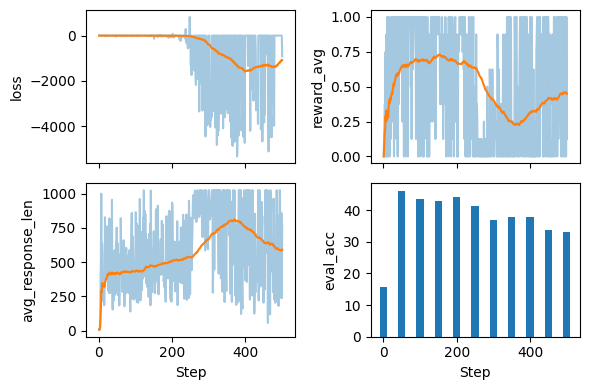

In [5]:
import csv
import matplotlib.pyplot as plt


def moving_average(values, window_fraction=0.25):
    # Smooth a noisy training signal to reveal longer-term trends during training
    window_size = max(1, int(window_fraction * len(values)))
    smoothed = []

    for i in range(len(values)):
        start_idx = max(0, i - window_size + 1)
        window_mean = sum(values[start_idx : i + 1]) / (i - start_idx + 1)
        smoothed.append(window_mean)

    return smoothed


def plot_grpo_metrics(csv_path, columns, save_as=None):
    data = {name: {"steps": [], "values": []} for name in columns}

    # Open and read CSV log file
    with Path(csv_path).open(newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if not row or not row.get("step"):
                continue

            # Use the training step as the shared x-axis across all metrics
            step = int(row["step"])

            for name in columns:
                value_str = row.get(name)
                if value_str:
                    data[name]["steps"].append(step)
                    data[name]["values"].append(float(value_str))

    # Create a fixed grid so loss, rewards, response length, etc. can be shown side by side
    fig, axes = plt.subplots(2, 2, sharex=True, figsize=(6, 4))
    axes = axes.ravel()

    for i, name in enumerate(columns):
        steps = data[name]["steps"]
        values = data[name]["values"]

        # Skip metrics that are not present
        if not values:
            fig.delaxes(axes[i])
            continue

        # Evaluation accuracy as barplot because we don't have data for each step
        if name == "eval_acc":
            axes[i].bar(steps, values, width=20)
        else:
            axes[i].plot(steps, values, alpha=0.4)
            axes[i].plot(steps, moving_average(values))

        axes[i].set_ylabel(name)

    for j in (2, 3):
        if axes[j] in fig.axes:
            axes[j].set_xlabel("Step")

    plt.tight_layout()
    if save_as is not None:
        plt.savefig(save_as)
    plt.show()


# Plot the GRPO training run
plot_grpo_metrics(
    "ch06_rlvr_grpo_original_no_kl_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"],
    # save_as="4.pdf"
)

In [6]:
download_from_github(
    "ch03/02_math500-verifier-scripts/evaluate_math500.py"
)

evaluate_math500.py: 3.5 KB


In [11]:
import torch

def compute_advantage_stats(rewards_list):
    rewards = torch.tensor(rewards_list)
    advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)

    adv_avg = advantages.mean().item()
    adv_std = advantages.std().item()

    return advantages, adv_avg, adv_std

In [12]:
adv, adv_avg, adv_std = compute_advantage_stats([1., 1., 0., 0.])

print(f"Advantages: {adv}")
print(f"Advantage mean = {adv_avg:.4f}, std = {adv_std:.4f}")

Advantages: tensor([ 0.8659,  0.8659, -0.8659, -0.8659])
Advantage mean = 0.0000, std = 0.9998


In [13]:
adv, adv_avg, adv_std = compute_advantage_stats([0., 0., 0., 0.])
print(f"Advantages: {adv}")
print(f"Advantage mean = {adv_avg:.4f}, std = {adv_std:.4f}")

Advantages: tensor([0., 0., 0., 0.])
Advantage mean = 0.0000, std = 0.0000


In [25]:
adv, adv_avg, adv_std = compute_advantage_stats([1., 1., 1., 1.])
print(f"Advantages: {adv}")
print(f"Advantage mean = {adv_avg:.4f}, std = {adv_std:.4f}")

Advantages: tensor([0., 0., 0., 0.])
Advantage mean = 0.0000, std = 0.0000


In [15]:
logits = torch.tensor([
    0.6667, -2.0000, 1.3333, -0.0000, -0.6667, 2.0000, -1.3333
])

In [18]:
logprobs = torch.log_softmax(logits, dim = -1)
print("All token logprobs:", logprobs)

selectd_token = torch.argmax(logprobs)

selectd = logprobs[selectd_token]
print("Selected token ID:", selectd_token)
print("Selectd token logprob:", selectd)

All token logprobs: tensor([-2.0442, -4.7109, -1.3776, -2.7109, -3.3776, -0.7109, -4.0442])
Selected token ID: tensor(5)
Selectd token logprob: tensor(-0.7109)


In [19]:
probs = torch.softmax(logits, dim=-1)
logprobs = torch.log_softmax(logits, dim=-1)

entropy = torch.sum(-(probs * logprobs))

print("Probs:", probs)
print("Entropy:", entropy)

Probs: tensor([0.1295, 0.0090, 0.2522, 0.0665, 0.0341, 0.4912, 0.0175])
Entropy: tensor(1.3700)


In [20]:
print("Probs:", torch.exp(logprobs))

Probs: tensor([0.1295, 0.0090, 0.2522, 0.0665, 0.0341, 0.4912, 0.0175])


In [21]:
def sequence_logprob_and_entropy(model, token_ids, prompt_len):
    logits = model(token_ids.unsqueeze(0)).squeeze(0).float()
    logprobs = torch.log_softmax(logits, dim=-1)

    targets = token_ids[1:]
    selectd = logprobs[:-1].gather(1, targets.unsqueeze(-1)).squeeze(-1)

    selected_answer_logprobs = selectd[prompt_len - 1:]
    logp_all_steps = torch.sum(selected_answer_logprobs)

    all_answer_logprobs = logprobs[:-1][prompt_len - 1:]
    if all_answer_logprobs.numel() == 0:
        entropy_all_steps = logp_all_steps.new_tensor(0.0)
    else:
        all_answer_porbs = torch.exp(all_answer_logprobs)
        plogp = all_answer_porbs * all_answer_logprobs
        step_entropy = -torch.sum(plogp, dim=-1)
        entropy_all_steps = torch.mean(step_entropy)
    return logp_all_steps, entropy_all_steps

In [22]:
download_from_github(
    "ch07/03_rlvr_grpo_scripts_advanced/7_3_plus_tracking.py"
)

7_3_plus_tracking.py: 16.9 KB


In [23]:
download_from_github(
    "ch07/02_logs/7_3_plus_tracking_metrics.csv"
)

7_3_plus_tracking_metrics.csv: 39.0 KB


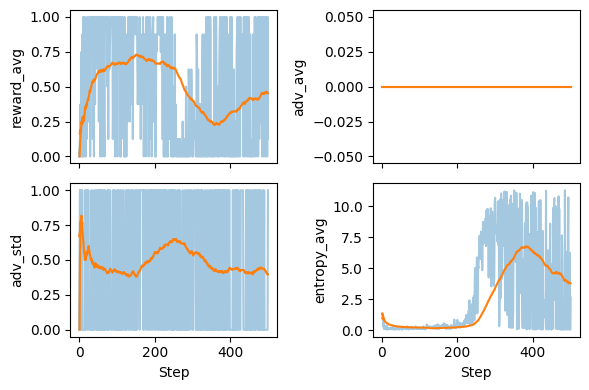

In [24]:
plot_grpo_metrics(
    "7_3_plus_tracking_metrics.csv",
    columns=["reward_avg", "adv_avg", "adv_std", "entropy_avg"],
    # save_as="9.pdf"
)

In [26]:
rewards = torch.tensor([1., 1., 0., 0.])

logprobs = torch.tensor([-7.9243, -20.1546, -16.6130, -23.3677])

advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)

pg_loss = -(advantages.detach() * logprobs).mean()
print("Policy gradient loss:", pg_loss)

Policy gradient loss: tensor(-2.5764)


In [28]:
new_logps = logprobs

old_logps = torch.tensor([
    -10.9243,   # -7.9243
    -20.3546,   # -20.1546
    -14.6130,   # -16.6130
    -23.3677,   # -23.3677
])

log_ratio = new_logps - old_logps

ratio = torch.exp(log_ratio)
clip_eps = 10.0
clipped_ratio = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps)

print("Ratio:        ", ratio)
print("Clipped ratio:", clipped_ratio)


Ratio:         tensor([20.0855,  1.2214,  0.1353,  1.0000])
Clipped ratio: tensor([11.0000,  1.2214,  0.1353,  1.0000])


In [29]:
adv = advantages.detach()

unclipped = ratio * adv
clipped = clipped_ratio * adv

obj = torch.where(
    adv >= 0,
    torch.minimum(unclipped, clipped),  # cap large positive updates
    torch.maximum(unclipped, clipped),  # cap large negative updates
)

clipped_pg_loss = -torch.mean(obj)
policy_ratio = torch.mean(ratio)

print("Clipped policy gradient loss:", clipped_pg_loss)
print("Policy ratio:", policy_ratio)

Clipped policy gradient loss: tensor(-2.3998)
Policy ratio: tensor(5.6106)


In [30]:
download_from_github(
    "ch07/03_rlvr_grpo_scripts_advanced/7_4_plus_clip_ratio.py"
)

7_4_plus_clip_ratio.py: 19.1 KB


In [31]:
download_from_github(
    "ch07/02_logs/7_4_plus_clip_ratio_metrics.csv",
)

7_4_plus_clip_ratio_metrics.csv: 42.7 KB


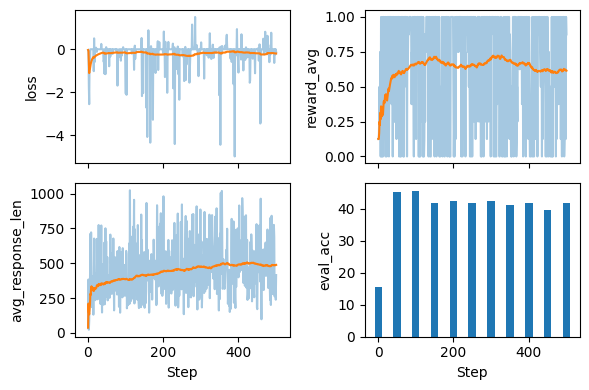

In [32]:
plot_grpo_metrics(
    "7_4_plus_clip_ratio_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"],
    save_as="13_1.pdf"
)

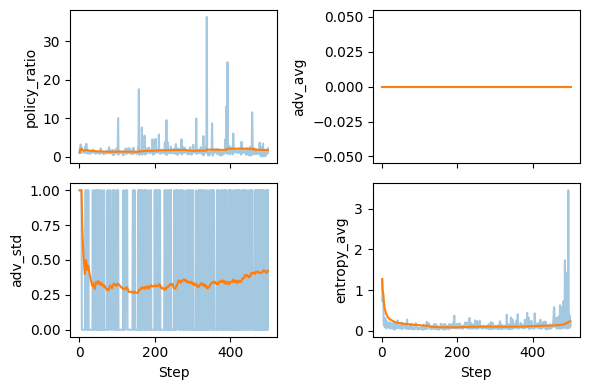

In [33]:
plot_grpo_metrics(
    "7_4_plus_clip_ratio_metrics.csv",
    columns=["policy_ratio", "adv_avg", "adv_std", "entropy_avg"],
    save_as="13_2.pdf"
)